<a href="https://colab.research.google.com/github/TWecks/Quantum-Error-Correction/blob/main/03_full_shor_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
!pip install qiskit-aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=150bc96511869573e171595c829320f25f1deee1e76380c4d13731a1fd12fd28
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
from qiskit import QuantumCircuit,transpile
from qiskit.visualization import plot_histogram
import qiskit_aer
from qiskit_aer import AerSimulator
from qiskit import ClassicalRegister, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.circuit.library import UGate



import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [3]:
# Prepare a perfect simulator
backend_sim_perfect = AerSimulator()

# Prepare a noisy simulator
from qiskit_aer.noise import NoiseModel,depolarizing_error,ReadoutError
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.02, 2), ['cx', 'cz'])
noise_model.add_all_qubit_quantum_error(depolarizing_error(4e-3, 1), ['id', 'z', 's', 'sdg', 't', 'tdg', 'x', 'rx', 'y', 'ry'])
noise_model.add_all_qubit_readout_error(ReadoutError([[0.98,0.02],[0.02,0.98]]))
backend_sim_noisy = AerSimulator(noise_model=noise_model)

# Building the Shor code: Concatenating

Now we begin building full Shor error-correcting code. What we'll be doing exlicitly is defining a set of gates on a 9-physical qubit quantum circut that will represent a single logical qubit and will run error correction.

The first step is to combine the logical qubits which will be resiliant to the X and Z errors. To do so we use the stratagey of *Concatenating*, literally combining our stratageys from before. Explicitly:


$|0_{LL} \rangle= H |0_L\rangle = \frac{1}{\sqrt{2}} (|0_L\rangle + |1_L\rangle)^{\otimes 3}= \frac{1}{\sqrt{2}} (|000 \rangle + |111\rangle)^{\otimes 3}$


$|1_{LL}\rangle = H |1_L\rangle = \frac{1}{\sqrt{2}} (|0_L\rangle - |1_L\rangle)^{\otimes 3} = \frac{1}{\sqrt{2}} (|000 \rangle - |111\rangle)^{\otimes 3}$

Which naturally means that an arbitrary state is written like

$\psi = \alpha |0_{LL} \rangle + \beta |1_{LL}\rangle = \frac{\alpha}{\sqrt{2}} (|000 \rangle + |111\rangle)^{\otimes 3} + \frac{\beta}{\sqrt{2}} (|000 \rangle - |111\rangle)^{\otimes 3}$

Designing the code in this way allows us to fix both X errors through the standard repetition code and Z errors through the hadamard-rotated repetition code.

As can be seen from the expressions, though, we now require nine physical qubits to encode a single logical qubit. Handily, we can reuse ancilla qubits between tests so we still only require two. Additionally, we can eliminate the need for X error corrections to use a classical register for syndrome detection, as we will see.

Now, let's initialize this encoding:

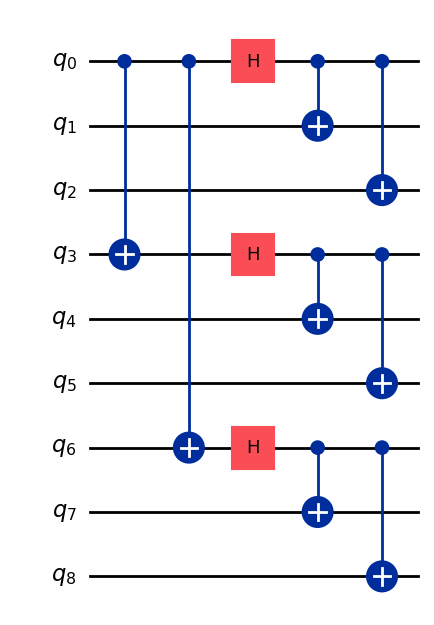

In [4]:
shor_code_construct = QuantumCircuit(9, 0)


shor_code_construct.cx(0,3)
shor_code_construct.cx(0,6)
shor_code_construct.h([0,3,6])
shor_code_construct.cx(0,1)
shor_code_construct.cx(0,2)
shor_code_construct.cx(3,4)
shor_code_construct.cx(3,5)
shor_code_construct.cx(6,7)
shor_code_construct.cx(6,8)


shor_code_decode = QuantumCircuit(9, 0)

shor_code_decode.cx(6,8)
shor_code_decode.cx(6,7)
shor_code_decode.cx(3,5)
shor_code_decode.cx(3,4)
shor_code_decode.cx(0,2)
shor_code_decode.cx(0,1)
shor_code_decode.h([0,3,6])
shor_code_decode.cx(0,6)
shor_code_decode.cx(0,3)


shor_code_construct.draw('mpl')


The "blocks" of our logical qubit are grouped (0,1,2), (3,4,5), (6,7,8). Since each block serves to protect against X errors, we can build a simple circut to analyze each block individuially and make the requiered correction. THis time, instead of feeding into a classical register, let's just act directly with a CX gate from the syndrome qubit. For this, then, we need 2 additional syndrome qubits, ancillas.  

# Implementing X Correction

To carry out X error correction, we can use the same code from the previous notebook applied once to each logical qubit block. Below this error correction circut is built, and we'll apply it in the final code:

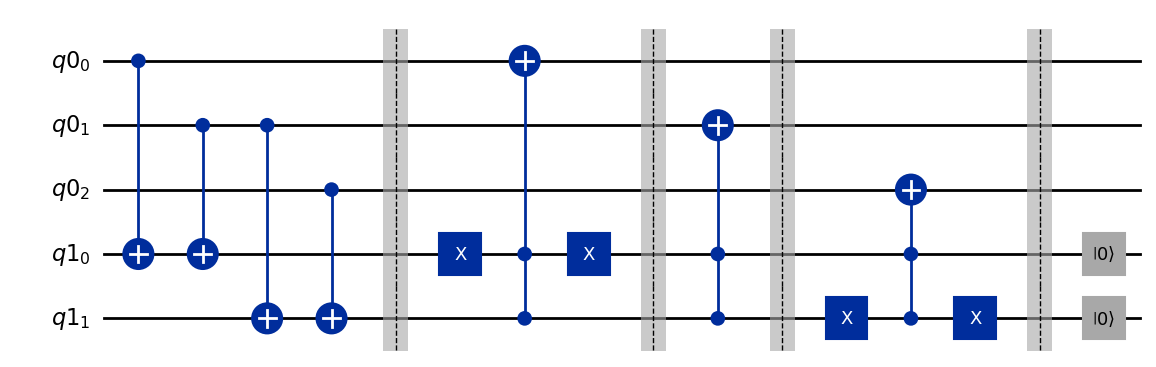

In [5]:
physical = QuantumRegister(3)
syndrome = QuantumRegister(2)

X_shor_code = QuantumCircuit(physical, syndrome)

X_shor_code.cx(0,3)
X_shor_code.cx(1,3)
X_shor_code.cx(1,4)
X_shor_code.cx(2,4)

#IF classical bits are 10, execute x gate on q0
#IF classical bits are 11, execute x gate on q1
#IF classical bits are 01, execute x gate on q2
#IF classical bits are 00 do nothing.


X_shor_code.barrier()
X_shor_code.x(3)
X_shor_code.ccx(3,4,0)
X_shor_code.x(3)
X_shor_code.barrier()
X_shor_code.ccx(3,4,1)
X_shor_code.barrier()
X_shor_code.x(4)
X_shor_code.ccx(3,4,2)
X_shor_code.x(4)
X_shor_code.barrier()
X_shor_code.reset([3,4])

X_shor_code.draw('mpl')


We can easially see how this is implemented over the full circut:

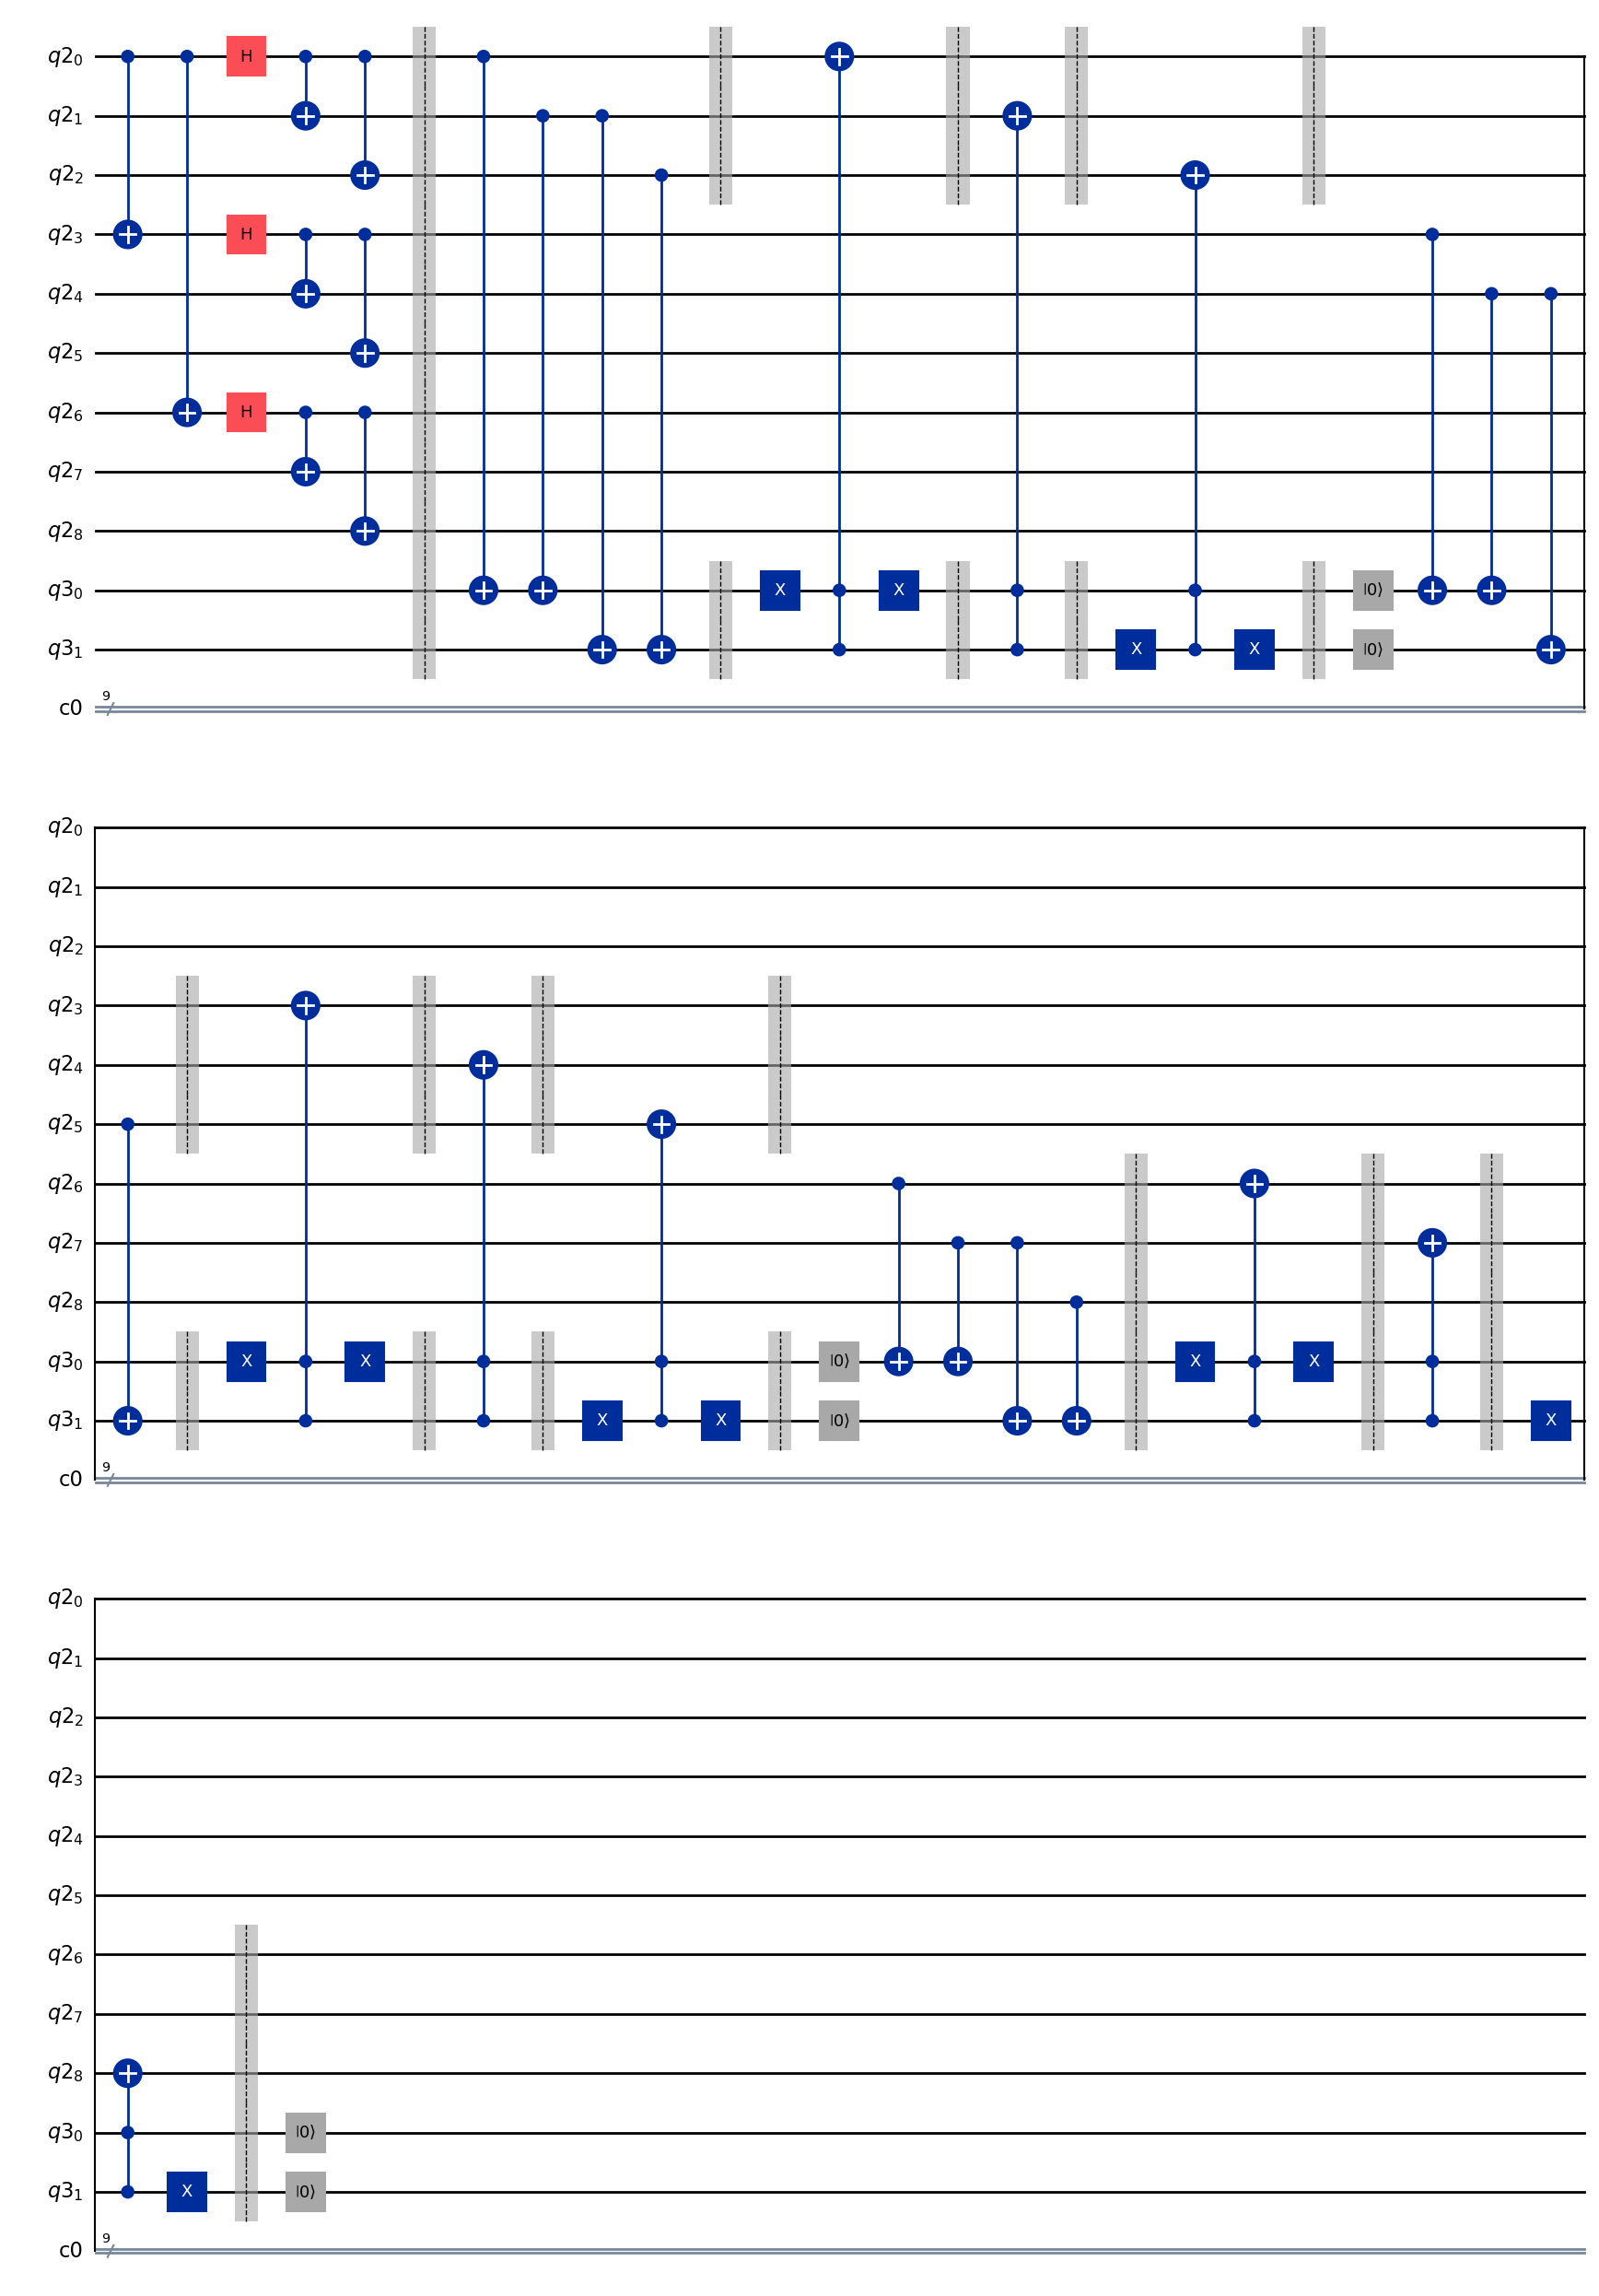

In [6]:
physical_qubits = QuantumRegister(9)
ancilla_qubit = QuantumRegister(2)
readout = ClassicalRegister(9)

#circut starts here

shor_with_x = QuantumCircuit(physical_qubits, ancilla_qubit, readout)

#initialize shor state

shor_with_x.compose(shor_code_construct, inplace=True)

shor_with_x.barrier()

#ERROR CORRECTION STEPS

#Block 1 X correction

shor_with_x.compose(
    X_shor_code,
    qubits=[physical_qubits[0], physical_qubits[1], physical_qubits[2], ancilla_qubit[0], ancilla_qubit[1]],
    inplace=True
)

#Block 2 X correction

shor_with_x.compose(
    X_shor_code,
    qubits=[physical_qubits[3], physical_qubits[4], physical_qubits[5], ancilla_qubit[0], ancilla_qubit[1]],
    inplace=True
)

#Block 3 X correction

shor_with_x.compose(
    X_shor_code,
    qubits=[physical_qubits[6], physical_qubits[7], physical_qubits[8], ancilla_qubit[0], ancilla_qubit[1]],
    inplace=True
)

shor_with_x.draw('mpl')

Great! Our concatenated code is now resilient against X errors.

# Implementing Z Correction

Lastly, we will implement Z error correction before running our tests. This step is a natural evolution of what was outlined for the 3-qubit case in the pervious notebook, and more information can be found on [IBM's website](https://quantum.cloud.ibm.com/learning/en/courses/foundations-of-quantum-error-correction/correcting-quantum-errors/shor-code), which is a fantastic resource for this entire exploration.

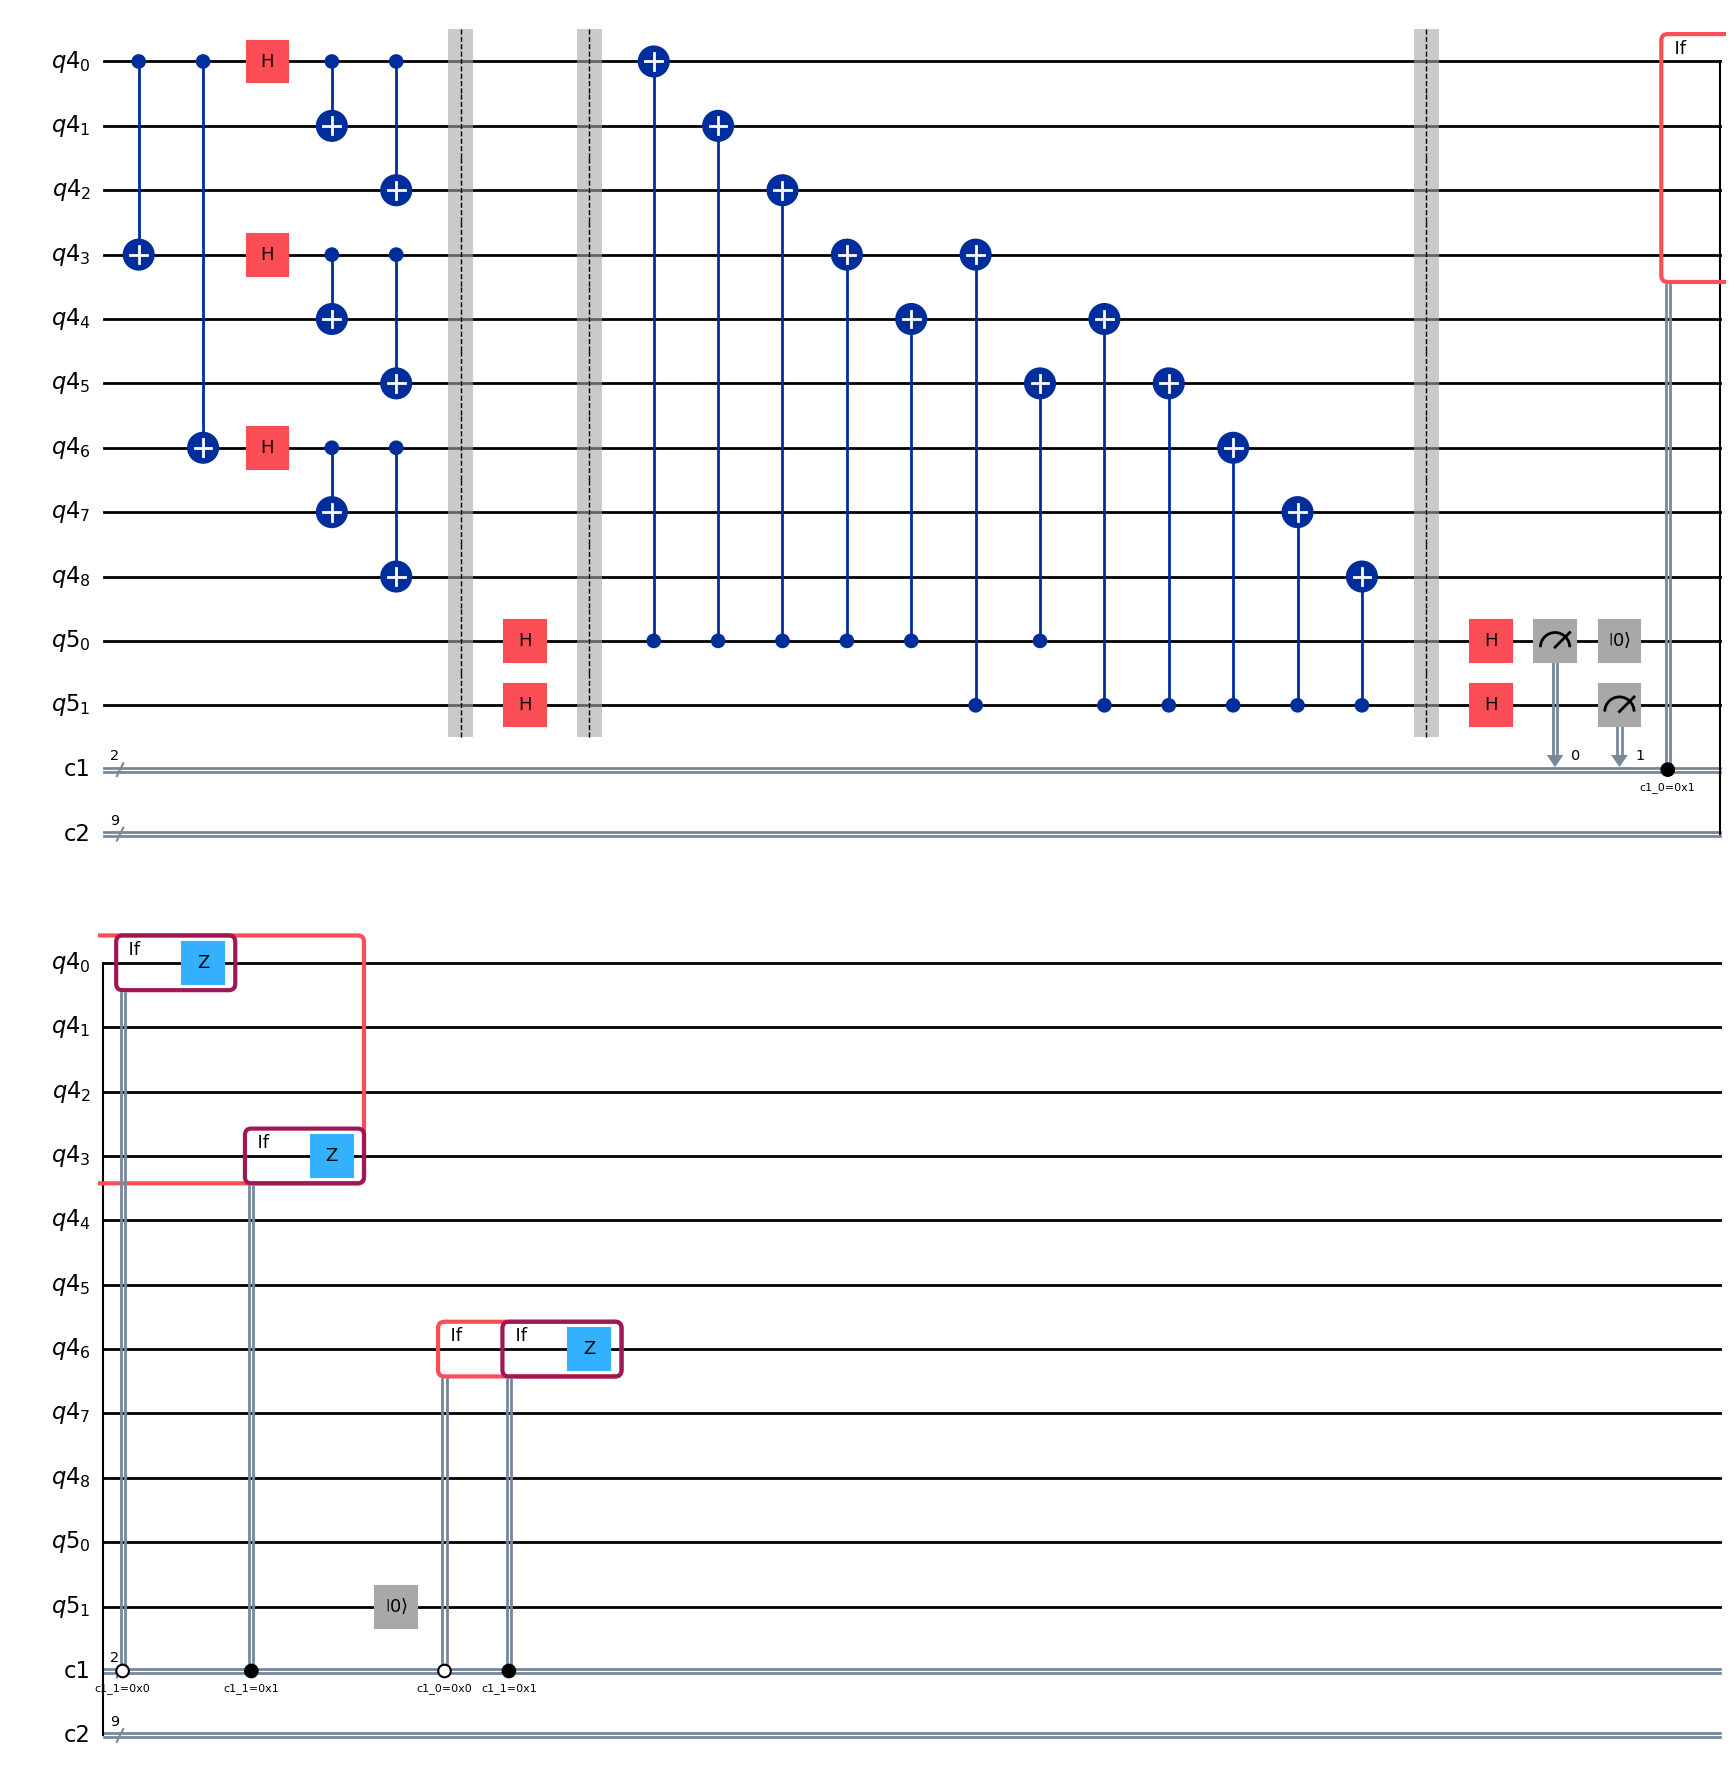

In [7]:
physical_qubits = QuantumRegister(9)
ancilla_qubit = QuantumRegister(2)
synd = ClassicalRegister(2)
readout = ClassicalRegister(9)

#circut starts here

shor_with_z = QuantumCircuit(physical_qubits, ancilla_qubit, synd, readout)

#initialize shor state

shor_with_z.compose(shor_code_construct, inplace=True)

shor_with_z.barrier()

#Z ERROR CORRECTION STEPS

#first, put ancilla qubits into the |+> state

shor_with_z.h([ancilla_qubit[0], ancilla_qubit[1]])

shor_with_z.barrier()

shor_with_z.cx(ancilla_qubit[0], physical_qubits[0])
shor_with_z.cx(ancilla_qubit[0], physical_qubits[1])
shor_with_z.cx(ancilla_qubit[0], physical_qubits[2])
shor_with_z.cx(ancilla_qubit[0], physical_qubits[3])
shor_with_z.cx(ancilla_qubit[0], physical_qubits[4])
shor_with_z.cx(ancilla_qubit[0], physical_qubits[5])

shor_with_z.cx(ancilla_qubit[1], physical_qubits[3])
shor_with_z.cx(ancilla_qubit[1], physical_qubits[4])
shor_with_z.cx(ancilla_qubit[1], physical_qubits[5])
shor_with_z.cx(ancilla_qubit[1], physical_qubits[6])
shor_with_z.cx(ancilla_qubit[1], physical_qubits[7])
shor_with_z.cx(ancilla_qubit[1], physical_qubits[8])

shor_with_z.barrier()

shor_with_z.h([ancilla_qubit[0], ancilla_qubit[1]])
shor_with_z.measure(ancilla_qubit[0], synd[0])
shor_with_z.measure(ancilla_qubit[1], synd[1])

#correct errors

with shor_with_z.if_test((synd[0], 1)):  # syndrome bit 0 = 1
    with shor_with_z.if_test((synd[1], 0)):  # syndrome bit 1 = 0 → top block
        shor_with_z.z(physical_qubits[0])  # any qubit from block 0
    with shor_with_z.if_test((synd[1], 1)):  # syndrome bit 1 = 1 → middle block
        shor_with_z.z(physical_qubits[3])  # any qubit from block 1

with shor_with_z.if_test((synd[0], 0)):
    with shor_with_z.if_test((synd[1], 0)):  # syndrome bit 1 = 0 → Pass, no error
        pass
    with shor_with_z.if_test((synd[1], 1)):  # syndrome bit 1 = 1 → bottom block
        shor_with_z.z(physical_qubits[6])  # any qubit from block 1








shor_with_z.reset([ancilla_qubit[0], ancilla_qubit[1]])





shor_with_z.draw('mpl')


Great again! Our concatenated code is now resilient against Z errors. Now we'll put it all together.

# The Full Error Correcting Shor Code with 9 Qubits

Now we put it all together. Thankfully, correcting these errors now is as simple as carrying out Z correction followed by X correction on each block!

We'll design the code such that the error will be knowingly injected on the 4th qubit, via a U gate which implements an SU(2) rotation on the qubit. By selecting values of Θ, ϕ, and λ we can have this U gate become an X, Z, I, XZ gate, or be the product of two arbitrary rotations Rx and Rz.

So that we have something to compare against, we also introduce a short circut that implements this error without any correction.

In [11]:


phi_error = Parameter('ϕ')
theta_error = Parameter('Θ')
lam_error = Parameter('λ')


qr = QuantumRegister(9)
anc = QuantumRegister(2)
synd = ClassicalRegister(2)
readout = ClassicalRegister(9)

shor_code = QuantumCircuit(qr, anc, synd, readout)

#initialize

shor_code.h(0)

shor_code.compose(shor_code_construct, inplace=True)

shor_code.barrier()

#seed errors here


shor_code.u(theta_error, phi_error, lam_error, qr[4])

shor_code.barrier()


# ----  Z ERROR CORRECTION STEPS ----

#first, put ancilla qubits into the |+> state

shor_code.h([anc[0], anc[1]])

shor_code.barrier()

shor_code.cx(anc[0], qr[0])
shor_code.cx(anc[0], qr[1])
shor_code.cx(anc[0], qr[2])
shor_code.cx(anc[0], qr[3])
shor_code.cx(anc[0], qr[4])
shor_code.cx(anc[0], qr[5])

shor_code.cx(anc[1], qr[3])
shor_code.cx(anc[1], qr[4])
shor_code.cx(anc[1], qr[5])
shor_code.cx(anc[1], qr[6])
shor_code.cx(anc[1], qr[7])
shor_code.cx(anc[1], qr[8])

shor_code.barrier()

shor_code.h([anc[0], anc[1]])
shor_code.measure(anc[0], synd[0])
shor_code.measure(anc[1], synd[1])

#correct errors

with shor_code.if_test((synd[0], 1)):  # syndrome bit 0 = 1
    with shor_code.if_test((synd[1], 0)):  # syndrome bit 1 = 0 → top block
        shor_code.z(qr[0])  # any qubit from block 0
    with shor_code.if_test((synd[1], 1)):  # syndrome bit 1 = 1 → middle block
        shor_code.z(qr[3])  # any qubit from block 1

with shor_code.if_test((synd[0], 0)):
    with shor_code.if_test((synd[1], 0)):  # syndrome bit 1 = 0 → Pass, no error
        pass
    with shor_code.if_test((synd[1], 1)):  # syndrome bit 1 = 1 → bottom block
        shor_code.z(qr[6])  # any qubit from block 2

shor_code.reset([anc[0], anc[1]])


shor_code.barrier()

# ----  X ERROR CORRECTION STEPS ----

#ERROR CORRECTION STEPS

#Block 1 X correction

shor_code.compose(
    X_shor_code,
    qubits=[qr[0], qr[1], qr[2], anc[0], anc[1]],
    inplace=True
)

#Block 2 X correction

shor_code.compose(
    X_shor_code,
    qubits=[qr[3], qr[4], qr[5], anc[0], anc[1]],
    inplace=True
)

#Block 3 X correction

shor_code.compose(
    X_shor_code,
    qubits=[qr[6], qr[7], qr[8], anc[0], anc[1]],
    inplace=True
)
#decode and readout

shor_code.barrier()
shor_code.compose(shor_code_decode, qubits=qr[:], inplace=True)
shor_code.barrier()
shor_code.measure(qr, readout)


# ----------------------------------------------------------------

# The UNCORRECTED code - testing against known errors.


uncorrected_shor = QuantumCircuit(qr, anc, synd, readout)

#initialize
uncorrected_shor.h(0)
uncorrected_shor.compose(shor_code_construct, inplace=True)
uncorrected_shor.barrier()

#seed errors here

uncorrected_shor.u(theta_error, phi_error, lam_error, qr[4])

uncorrected_shor.barrier()

#decode and readout
uncorrected_shor.barrier()
uncorrected_shor.compose(shor_code_decode, qubits=qr[:], inplace=True)
uncorrected_shor.barrier()
uncorrected_shor.measure(qr, readout)







This circut is quite large, you can run this code to view it if you would like:


In [15]:
#shor_code.draw('mpl')
#uncorrected_shor.draw('mpl')

And now we can plot, choosing values for our parameters to have either no error, X error only, Z error only, or XZ error together. Note that our final decoded state should be the $|000000001\rangle$ or $|000000000\rangle$ state with equal probability, since we are initializing $q_0$, the primary qubit, to $\frac{1}{\sqrt{2}}(|0\rangle + | 1 \rangle )$ .  

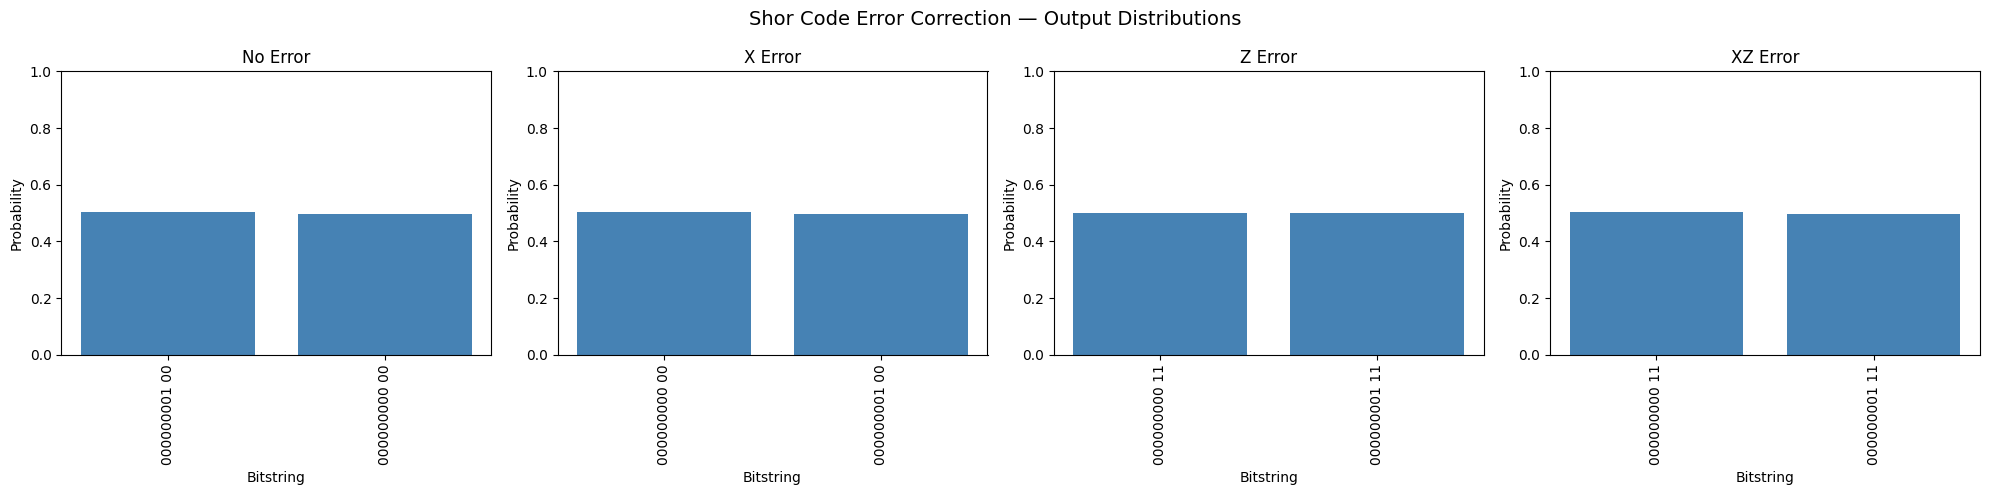

In [10]:
sim = AerSimulator()
shots = 10000

# --- define error cases ---
error_cases = {
    'No Error':   (0, 0, 0),
    'X Error':    (np.pi, 0, np.pi),
    'Z Error':    (0, 0, np.pi),
    'XZ Error':   (np.pi, np.pi/2, np.pi/2),
}

# --- run each case ---
all_counts = {}

for label, (theta, phi, lam) in error_cases.items():
    bound = shor_code.assign_parameters({
        theta_error: theta,
        phi_error: phi,
        lam_error: lam
    })
    transpiled = transpile(bound, sim)
    result = sim.run(transpiled, shots=shots).result()
    all_counts[label] = result.get_counts()

# --- plot ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (label, counts) in zip(axes, all_counts.items()):
    # sort by count for readability
    sorted_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:10])
    probs = {k: v/shots for k, v in sorted_counts.items()}
    ax.bar(probs.keys(), probs.values(), color='steelblue')
    ax.set_title(label)
    ax.set_xlabel('Bitstring')
    ax.set_ylabel('Probability')
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(0, 1)

plt.suptitle('Shor Code Error Correction — Output Distributions', fontsize=14)
plt.tight_layout()
plt.show()



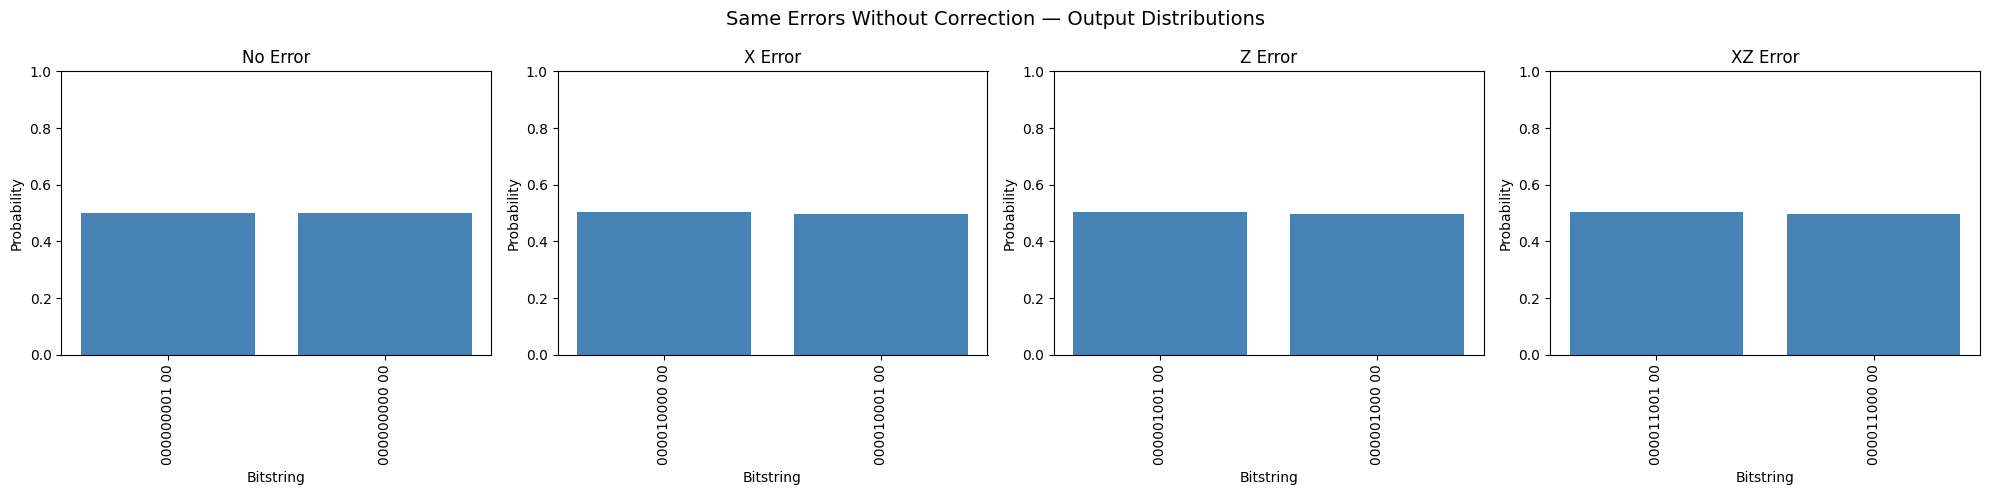

In [13]:
sim = AerSimulator()
shots = 10000

# --- define error cases ---
error_cases = {
    'No Error':   (0, 0, 0),
    'X Error':    (np.pi, 0, np.pi),
    'Z Error':    (0, 0, np.pi),
    'XZ Error':   (np.pi, np.pi/2, np.pi/2),
}

# --- run each case ---
all_counts = {}

for label, (theta, phi, lam) in error_cases.items():
    bound = uncorrected_shor.assign_parameters({
        theta_error: theta,
        phi_error: phi,
        lam_error: lam
    })
    transpiled = transpile(bound, sim)
    result = sim.run(transpiled, shots=shots).result()
    all_counts[label] = result.get_counts()

# --- plot ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (label, counts) in zip(axes, all_counts.items()):
    # sort by count for readability
    sorted_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:10])
    probs = {k: v/shots for k, v in sorted_counts.items()}
    ax.bar(probs.keys(), probs.values(), color='steelblue')
    ax.set_title(label)
    ax.set_xlabel('Bitstring')
    ax.set_ylabel('Probability')
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(0, 1)

plt.suptitle('Same Errors Without Correction — Output Distributions', fontsize=14)
plt.tight_layout()
plt.show()


And there it is! We get the expected bitstrings returned for each type of error with probability $\frac{1}{2}$ when we run error correction, and different bitstrings (reflecting errors) when we don't run correction. Notice that for the "no error" case, we do get the proper result because (of course) there was no error.

 The final two enteries in the bitstring are our syndrome classical register, which, by taking value 11 in the case of a Z error on the central block, demonstrate that our code is indeed detecting the error and correcting properly.
Note that in the second set of graphs, since we're not running the correcting code, the final two registers are always 00 since we're not measuring for Z error.

# Conclusion

Thank you for joining me on this exploration! If you have any questions, comments, or would like to chat you can reach me via [LinkedIn](https://www.linkedin.com/in/theodore-wecker/) or my personal website: [twecker.com/contact](https://twecker.com/contact).


Cheers!